In [ ]:
%matplotlib inline

In [16]:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
import pickle
from behave_analysis.utils.arena_plotting import Arena
import matplotlib.pyplot as plt
from behave_analysis.homings.homings import cum_distance


In [3]:
# Load escape objects for each session
JAL1_SEQ3_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\escapes\escapes_obj.pkl"
JAL1_SEQ3_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\fully_processed_tracking_data.pickle"
with open(JAL1_SEQ3_obj, 'rb') as f:
    JAL1_SEQ3_escapes = pickle.load(f)
with open(JAL1_SEQ3_tracking_data_file, 'rb') as f:
    JAL1_SEQ3_tracking_data = pickle.load(f)

JAL1_SEQ2_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\escapes\escapes_obj.pkl"
JAL1_SEQ2_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\fully_processed_tracking_data.pickle"
with open(JAL1_SEQ2_obj, 'rb') as f:
    JAL1_SEQ2_escapes = pickle.load(f)
with open(JAL1_SEQ2_tracking_data_file, 'rb') as f:
    JAL1_SEQ2_tracking_data = pickle.load(f)

JAL2_SEQ2_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\escapes\escapes_obj.pkl"
JAL2_SEQ2_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\fully_processed_tracking_data.pickle"
with open(JAL2_SEQ2_obj, 'rb') as f:
    JAL2_SEQ2_escapes = pickle.load(f)
with open(JAL2_SEQ2_tracking_data_file, 'rb') as f:
    JAL2_SEQ2_tracking_data = pickle.load(f)

JAL2_SEQ3_obj = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\escapes\escapes_obj.pkl"
JAL2_SEQ3_tracking_data_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\fully_processed_tracking_data.pickle"
with open(JAL2_SEQ3_obj, 'rb') as f:
    JAL2_SEQ3_escapes = pickle.load(f)
with open(JAL2_SEQ3_tracking_data_file, 'rb') as f:
    JAL2_SEQ3_tracking_data = pickle.load(f)

In [ ]:
JAL2_SEQ3_tracking_data.keys()

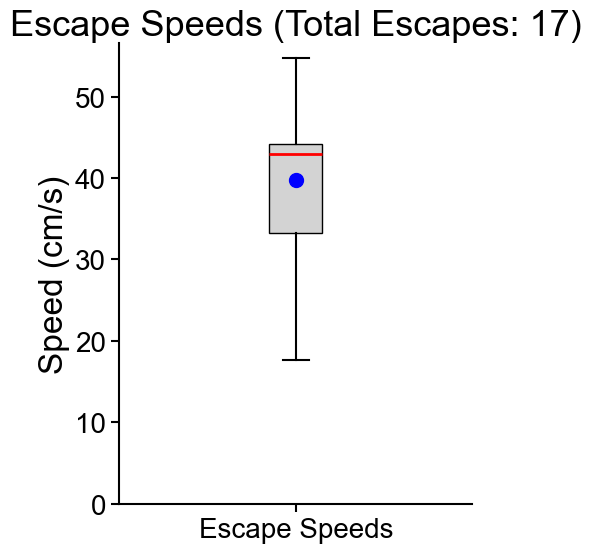

In [4]:
%matplotlib inline

import pickle
import numpy as np
import os

# Escape objects for each session
sessions = {
    "JAL1_SEQ3": JAL1_SEQ3_escapes,
    "JAL1_SEQ2": JAL1_SEQ2_escapes,
    "JAL2_SEQ2": JAL2_SEQ2_escapes,
    "JAL2_SEQ3": JAL2_SEQ3_escapes,
}

# Collect all escape speeds across all sessions
all_escape_speeds = []
for session_name, escapes in sessions.items():
    # If avg_speed is a sequence, extend the list with all escape speeds
    if isinstance(escapes.avg_speed, (list, np.ndarray)):
        all_escape_speeds.extend(escapes.avg_speed)
    else:
        all_escape_speeds.append(escapes.avg_speed)  # Add scalar value directly

# Calculate the mean of all escape speeds
mean_speed = np.mean(all_escape_speeds)

# Get the total number of escapes
total_escapes = len(all_escape_speeds)

# Plot the results as a box plot
plt.rcParams.update({
    "font.size": 22,  # Larger font size for publication
    "font.family": "Arial",
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

fig, ax = plt.subplots(figsize=(5, 6))  # Adjusted figure size for less white space

# Create the box plot
box = ax.boxplot(all_escape_speeds, patch_artist=True, boxprops=dict(facecolor="lightgrey", color="black"), 
                 medianprops=dict(color="red", linewidth=2), whiskerprops=dict(color="black", linewidth=1.5), 
                 capprops=dict(color="black", linewidth=1.5), flierprops=dict(marker='o', color='black', alpha=0.5))

# Add the mean as a separate marker
ax.plot(1, mean_speed, marker='o', color='blue', markersize=10)

# Add labels and formatting
ax.set_title(f"Escape Speeds (Total Escapes: {total_escapes})")  # Add total escapes to the title
ax.set_ylabel("Speed (cm/s)")
ax.set_xticks([1])
ax.set_xticklabels(["Escape Speeds"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)

# Set the Y-axis to start from 0
ax.set_ylim(bottom=0)

plt.tight_layout()
fig.savefig(os.path.join(save_path, "speed_quantification.eps"), format='eps', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
JAL1_SEQ3_escapes

In [ ]:
from behave_analysis.homings.homings import cum_distance

pixels_per_cm = 10  # Example value, replace with actual pixels per cm from your session data

def trajectory_by_target(onsets, offsets, tracking_data):
    """Plot the trajectory of all homings in each condition, colored by the target in the first 15 cm of the run"""
    conditions = ["barrier_present"]
    _, ax = plt.subplots(nrows=1, ncols=len(conditions), figsize=(20, 4))
    for i, con in enumerate(conditions):
        sum_homings = 0
        for idx, (onset,offset) in enumerate(zip(onsets,offsets)):
            
            frame_coords = tracking_data["avg_loc"][onset:offset]
            _, start_frame = cum_distance(onset, offset, frame_coords, pixels_per_cm, 15)

            # calculate the preference of mouse heading for one of three targets - could also use start_frame or the average from start_frame to end_fr
            xdist = -tracking_data['head_loc'][start_frame, 0]+tracking_data['barrier_loc'][0][0]
            ydist = -tracking_data['head_loc'][start_frame, 1]+tracking_data['barrier_loc'][0][1]
            bprea = - np.arctan2(ydist, xdist)
            xdist = -tracking_data['head_loc'][start_frame, 0]+tracking_data['barrier_loc'][1][0]
            ydist = -tracking_data['head_loc'][start_frame, 1]+tracking_data['barrier_loc'][1][1]
            bposta = - np.arctan2(ydist, xdist)
            if tracking_data["bod_shelt_dir"][start_frame] < 0: bsa = tracking_data["bod_shelt_dir"][start_frame] + np.pi
            if tracking_data["bod_shelt_dir"][start_frame] > 0:  bsa = tracking_data["bod_shelt_dir"][start_frame] - np.pi

            # cosim=[]
            # for ang in [bprea,bsa, bposta]:
            #     cosim = np.append(cosim,np.cos(ang-head_angle[idx]))
            # color = ['green','red','blue']

            x_loc = tracking_data["head_loc"][onset : offset, 0]
            y_loc = tracking_data["head_loc"][onset : offset, 1]
            ax.scatter(x_loc, y_loc, s=3)
            #ax[i].scatter(x_loc, y_loc, s=3, color=color[np.argmax(cosim)])


        Arena(ax=ax, shelter_coordinates=tracking_data["shelter_loc"], condition=con, barrier_coordinates=tracking_data["barrier_loc"])
        ax.set_title(f"{con} (n={sum_homings})")


In [ ]:
import matplotlib.pyplot as plt

def plot_trajectories_for_sessions(sessions):
    """
    Create one plot with four subplots, each representing a session.
    All scatter plots will use the same color and include the number of escapes in the title.
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })

    fig, axes = plt.subplots(2, 2, figsize=(14, 14))  # Create a 2x2 grid of subplots
    fig.suptitle("Escape Trajectories Across Sessions", fontsize=22)  # Add a main title

    # Define session titles
    session_titles = ["JAL1_SEQ3", "JAL1_SEQ2", "JAL2_SEQ2", "JAL2_SEQ3"]

    # Loop through each session and plot its trajectories
    for ax, (session_title, (onsets, offsets, tracking_data)) in zip(axes.flatten(), sessions.items()):
        num_escapes = len(onsets)  # Calculate the number of escapes for the session

        for onset, offset in zip(onsets, offsets):
            # Extract trajectory data
            x_loc = tracking_data["head_loc"][onset:offset, 0]
            y_loc = tracking_data["head_loc"][onset:offset, 1]

            # Plot the trajectory
            ax.scatter(x_loc, y_loc, s=3, color="steelblue", alpha=1)  # Use a visually appealing color

        # Add session title with the number of escapes
        ax.set_title(f"{session_title} (n={num_escapes})", fontsize=16)
        ax.set_xlabel("X Position (cm)", fontsize=14)
        ax.set_ylabel("Y Position (cm)", fontsize=14)
        ax.set_aspect('equal', adjustable='box')

        # Add the arena outline and shelter
        Arena(ax=ax, shelter_coordinates=tracking_data["shelter_loc"], condition="barrier_present", barrier_coordinates=tracking_data["barrier_loc"])

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the main title
    plt.savefig(os.path.join(save_path, "escape_trajectories.eps"), format='eps', bbox_inches='tight', dpi=300)
    
     
sessions = {
    "JAL1_SEQ3": (JAL1_SEQ3_escapes.escape_onset_frames, JAL1_SEQ3_escapes.escape_end_frames, JAL1_SEQ3_tracking_data),
    "JAL1_SEQ2": (JAL1_SEQ2_escapes.escape_onset_frames, JAL1_SEQ2_escapes.escape_end_frames, JAL1_SEQ2_tracking_data),
    "JAL2_SEQ2": (JAL2_SEQ2_escapes.escape_onset_frames, JAL2_SEQ2_escapes.escape_end_frames, JAL2_SEQ2_tracking_data),
    "JAL2_SEQ3": (JAL2_SEQ3_escapes.escape_onset_frames, JAL2_SEQ3_escapes.escape_end_frames, JAL2_SEQ3_tracking_data),
}

# Plot trajectories for all sessions
plot_trajectories_for_sessions(sessions)

In [ ]:
import matplotlib.pyplot as plt

def plot_escape_summary(shelter_escapes, non_shelter_escapes):
    """
    Create a bar plot showing the number of escapes that terminated at the shelter
    versus those that did not.
    """
    # Data for the bar plot
    categories = ["Shelter", "Non-Shelter"]
    counts = [shelter_escapes, non_shelter_escapes]

    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })

    # Create the bar plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.bar(categories, counts, color=["steelblue", "darkorange"], alpha=0.8)

    # Add labels and title
    ax.set_title("Escape Termination Summary", fontsize=18)
    ax.set_ylabel("Number of Escapes", fontsize=16)
    ax.set_xlabel("Termination Location", fontsize=16)

    # Add counts above the bars
    for i, count in enumerate(counts):
        ax.text(i, count + 0.5, str(count), ha="center", fontsize=14)

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "escape_termination_summary.eps"), format='eps', bbox_inches='tight', dpi=300)

# Example data
shelter_escapes = 16
non_shelter_escapes = 1

# Plot the summary
plot_escape_summary(shelter_escapes, non_shelter_escapes)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import os

def plot_escape_summary(shelter_escapes, non_shelter_escapes):
    """
    Create a bar plot showing the number of escapes that terminated at the shelter
    versus those that did not, with statistical significance.
    """
    # Data for the bar plot
    categories = ["Shelter", "Non-Shelter"]
    counts = [shelter_escapes, non_shelter_escapes]
    
    # Perform binomial test (testing if proportion of shelter escapes differs from chance)
    # H0: p = 0.5 (equal probability of shelter vs. non-shelter)
    total_escapes = shelter_escapes + non_shelter_escapes
    
    # Use binomtest instead of the deprecated binom_test
    binomial_result = stats.binomtest(shelter_escapes, n=total_escapes, p=0.5, alternative='two-sided')
    binom_p_value = binomial_result.pvalue
    
    # Determine significance marker
    if binom_p_value < 0.001:
        sig_marker = '***'
    elif binom_p_value < 0.01:
        sig_marker = '**'
    elif binom_p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'n.s.'

    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })

    # Create the bar plot
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(categories, counts, color=["steelblue", "darkorange"], alpha=0.8)

    # Add labels and title
    ax.set_title("Escape Termination Summary", fontsize=18)
    ax.set_ylabel("Number of Escapes", fontsize=16)
    ax.set_xlabel("Termination Location", fontsize=16)

    # Add counts above the bars
    for i, count in enumerate(counts):
        ax.text(i, count + 0.5, str(count), ha="center", fontsize=14)

    # Add significance bar and star
    y_max = max(counts)
    bar_height = y_max + 2
    ax.plot([0, 1], [bar_height, bar_height], 'k-', linewidth=1.5)
    ax.text(0.5, bar_height + 0.5, sig_marker, ha='center', va='bottom', fontsize=16, fontweight='bold')
    
    # Add p-value text
    p_value_text = f"p = {binom_p_value:.4f}" if binom_p_value >= 0.0001 else "p < 0.0001"
    ax.text(0.5, bar_height - 1.5, p_value_text, ha='center', va='bottom', fontsize=12)

    # Set y-axis limit to accommodate the significance marker
    ax.set_ylim(0, bar_height + 3)

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)

    plt.tight_layout()
    save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
    plt.savefig(os.path.join(save_path, "escape_termination_summary.eps"), format='eps', bbox_inches='tight', dpi=300)
    
    
    # Print statistical results for reference
    print(f"Binomial test results:")
    print(f"Number of escapes terminating at shelter: {shelter_escapes}")
    print(f"Number of escapes not terminating at shelter: {non_shelter_escapes}")
    print(f"Total escapes: {total_escapes}")
    print(f"P-value: {binom_p_value:.6f}")
    print(f"Significance: {sig_marker}")
    
    return fig

In [ ]:
plot_escape_summary(shelter_escapes, non_shelter_escapes)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from behave_analysis.utils.arena_plotting import Arena

def plot_initial_heading_angle(sessions):
    """
    Plot the initial heading angle for each session. Each subplot represents a session,
    showing the mouse's heading before and after the head turn, colored by the target it is heading toward.
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })

    fig, axes = plt.subplots(2, 2, figsize=(14, 14))  # Create a 2x2 grid of subplots
    fig.suptitle("Initial Heading Angles Across Sessions", fontsize=22)  # Add a main title

    # Define session titles
    session_titles = ["JAL1_SEQ3", "JAL1_SEQ2", "JAL2_SEQ2", "JAL2_SEQ3"]

    # Loop through each session and plot its initial heading angles
    for ax, (session_title, (onsets, offsets, tracking_data, escapes)) in zip(axes.flatten(), sessions.items()):
        sum_homings = 0
        length = 180  # Length of the arrows

        for onset, offset, avg_hdir in zip(onsets, offsets, escapes.head_orientation["avg_hdir"]):
            if np.isnan(onset):
                continue

            # Calculate the start frame based on cumulative distance
            frame_coords = tracking_data["avg_loc"][onset:offset]
            _, start_frame = cum_distance(onset, offset, frame_coords, pixels_per_cm=10, cum_threshold=15)

            # Extract initial heading direction and position
            mouse_start = tracking_data["avg_loc"][onset - 1]
            dx_start = length * np.cos(avg_hdir)
            dy_start = length * -np.sin(avg_hdir)
            ax.scatter(mouse_start[0], mouse_start[1], color="black")
            ax.quiver(mouse_start[0], mouse_start[1], dx_start, dy_start, angles="xy", scale_units="xy", scale=2, color="black")

            # Extract heading direction after the head turn
            mouse_run = tracking_data["head_loc"][start_frame]
            dx_run = length * np.cos(avg_hdir)
            dy_run = length * -np.sin(avg_hdir)

            # Calculate cosine similarity for target preference
            xdist = -tracking_data["head_loc"][start_frame, 0] + tracking_data["barrier_loc"][0][0]
            ydist = -tracking_data["head_loc"][start_frame, 1] + tracking_data["barrier_loc"][0][1]
            bprea = -np.arctan2(ydist, xdist)

            xdist = -tracking_data["head_loc"][start_frame, 0] + tracking_data["barrier_loc"][1][0]
            ydist = -tracking_data["head_loc"][start_frame, 1] + tracking_data["barrier_loc"][1][1]
            bposta = -np.arctan2(ydist, xdist)

            bsa = tracking_data["bod_shelt_dir"][start_frame]
            if bsa < 0:
                bsa += np.pi
            elif bsa > 0:
                bsa -= np.pi

            cosim = [np.cos(bprea - avg_hdir),
                     np.cos(bsa - avg_hdir),
                     np.cos(bposta - avg_hdir)]
            color = ["green", "red", "blue"]

            # Plot the heading direction after the head turn
            ax.scatter(mouse_run[0], mouse_run[1], color=color[np.argmax(cosim)])
            ax.quiver(mouse_run[0], mouse_run[1], dx_run, dy_run, angles="xy", scale_units="xy", scale=2, color=color[np.argmax(cosim)])

            sum_homings += 1

        # Add the arena outline and shelter
        Arena(ax=ax, shelter_coordinates=tracking_data["shelter_loc"], condition="barrier_present", barrier_coordinates=tracking_data["barrier_loc"])
        ax.set_title(f"{session_title} (n={sum_homings})", fontsize=16)
        ax.set_xlabel("X Position (cm)", fontsize=14)
        ax.set_ylabel("Y Position (cm)", fontsize=14)
        ax.set_aspect("equal", adjustable="box")

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the main title
    plt.savefig(os.path.join(save_path, "initial_heading_angles.eps"), format="eps", bbox_inches="tight", dpi=300)
    

# Prepare session data
sessions = {
    "JAL1_SEQ3": (JAL1_SEQ3_escapes.escape_onset_frames, JAL1_SEQ3_escapes.escape_end_frames, JAL1_SEQ3_tracking_data, JAL1_SEQ3_escapes),
    "JAL1_SEQ2": (JAL1_SEQ2_escapes.escape_onset_frames, JAL1_SEQ2_escapes.escape_end_frames, JAL1_SEQ2_tracking_data, JAL1_SEQ2_escapes),
    "JAL2_SEQ2": (JAL2_SEQ2_escapes.escape_onset_frames, JAL2_SEQ2_escapes.escape_end_frames, JAL2_SEQ2_tracking_data, JAL2_SEQ2_escapes),
    "JAL2_SEQ3": (JAL2_SEQ3_escapes.escape_onset_frames, JAL2_SEQ3_escapes.escape_end_frames, JAL2_SEQ3_tracking_data, JAL2_SEQ3_escapes),
}

# Plot initial heading angles for all sessions
plot_initial_heading_angle(sessions)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from behave_analysis.utils.arena_plotting import Arena

def plot_combined_initial_heading_angle(sessions):
    """
    Combine all initial heading angles into one plot and add a histogram showing the distribution of starting angles.
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 18,  # Larger font size for publication
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })

    fig, axes = plt.subplots(1, 2, figsize=(18, 9))  # Create a 1x2 grid of subplots
    fig.suptitle("Initial Heading Angles Across Sessions", fontsize=24, fontweight='bold')  # Add a main title

    combined_angles = []  # Collect all starting angles for the histogram
    length = 180  # Length of the arrows

    # First subplot: Combined initial heading arrows
    ax_arena = axes[0]
    for session_title, (onsets, offsets, tracking_data, escapes) in sessions.items():
        for onset, start_head_ori in zip(onsets, escapes.start_head_ori):
            if np.isnan(onset):
                continue

            # Extract the starting position of the mouse
            mouse_start = tracking_data["avg_loc"][onset - 1]

            # Calculate the arrow direction based on the initial heading orientation
            dx_start = length * np.cos(start_head_ori)
            dy_start = length * -np.sin(start_head_ori)

            # Plot the initial heading arrow
            ax_arena.scatter(mouse_start[0], mouse_start[1], color="black", alpha=0.7)
            ax_arena.quiver(mouse_start[0], mouse_start[1], dx_start, dy_start, angles="xy", scale_units="xy", scale=2, color="black", alpha=0.7)

            # Collect the starting angle for the histogram
            combined_angles.append(np.degrees(start_head_ori))  # Convert radians to degrees

    # Add the arena outline and shelter
    Arena(ax=ax_arena, shelter_coordinates=tracking_data["shelter_loc"], condition="barrier_present", barrier_coordinates=tracking_data["barrier_loc"])
    ax_arena.set_title("Combined Initial Heading Arrows", fontsize=20, fontweight='bold')
    ax_arena.set_xlabel("X Position (cm)", fontsize=18)
    ax_arena.set_ylabel("Y Position (cm)", fontsize=18)
    ax_arena.set_aspect("equal", adjustable="box")
    ax_arena.grid(True, linestyle='--', alpha=0.5)

    # Second subplot: Histogram of starting angles
    ax_hist = axes[1]
    ax_hist.hist(combined_angles, bins=20, color="steelblue", alpha=0.8, edgecolor="black")
    ax_hist.set_title("Distribution of Starting Angles", fontsize=20, fontweight='bold')
    ax_hist.set_xlabel("Angle (degrees)", fontsize=18)
    ax_hist.set_ylabel("Frequency", fontsize=18)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_hist.grid(True, linestyle='--', alpha=0.5)
    
    # Add a vertical line at 0 degrees
    ax_hist.axvline(0, color='red', linestyle='--', linewidth=2, label='0°')

    # Save the plot in high resolution
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the main title
    plt.savefig(os.path.join(save_path, "combined_initial_heading_angles_publication_ready.eps"), format="eps", bbox_inches="tight", dpi=300)
    

# Prepare session data
sessions = {
    "JAL1_SEQ3": (JAL1_SEQ3_escapes.escape_onset_frames, JAL1_SEQ3_escapes.escape_end_frames, JAL1_SEQ3_tracking_data, JAL1_SEQ3_escapes),
    "JAL1_SEQ2": (JAL1_SEQ2_escapes.escape_onset_frames, JAL1_SEQ2_escapes.escape_end_frames, JAL1_SEQ2_tracking_data, JAL1_SEQ2_escapes),
    "JAL2_SEQ2": (JAL2_SEQ2_escapes.escape_onset_frames, JAL2_SEQ2_escapes.escape_end_frames, JAL2_SEQ2_tracking_data, JAL2_SEQ2_escapes),
    "JAL2_SEQ3": (JAL2_SEQ3_escapes.escape_onset_frames, JAL2_SEQ3_escapes.escape_end_frames, JAL2_SEQ3_tracking_data, JAL2_SEQ3_escapes),
}

# Plot combined initial heading angles and histogram
plot_combined_initial_heading_angle(sessions)

In [10]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]



In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from behave_analysis.process.session import get_experiment

# Paths for the two-edge sessions
two_edge_sessions = {
    "JAL1_SEQ3": JAL1_SEQ3_escapes,
    "JAL1_SEQ2": JAL1_SEQ2_escapes,
    "JAL2_SEQ2": JAL2_SEQ2_escapes,
    "JAL2_SEQ3": JAL2_SEQ3_escapes,
}

# Experimental objects for one-edge sessions
one_edge_sessions = experiments_objects

# Function to collect escape speeds
def collect_escape_speeds(sessions, is_two_edge=True):
    escape_speeds = []
    if is_two_edge:
        # Collect escape speeds for two-edge sessions
        for session_name, escapes in sessions.items():
            if isinstance(escapes.avg_speed, (list, np.ndarray)):
                escape_speeds.extend(escapes.avg_speed)
            else:
                escape_speeds.append(escapes.avg_speed)
    else:
        # Collect escape speeds for one-edge sessions
        for session in sessions:
            loaded_session = get_experiment(session)
            escapes_path = os.path.join(
                loaded_session.base_path,
                loaded_session.processed_path,
                "escapes",
                "escapes_obj.pkl"
            )
            if os.path.exists(escapes_path):
                with open(escapes_path, 'rb') as f:
                    escapes = pickle.load(f)
                    if isinstance(escapes.avg_speed, (list, np.ndarray)):
                        escape_speeds.extend(escapes.avg_speed)
                    else:
                        escape_speeds.append(escapes.avg_speed)
    return escape_speeds

# Collect escape speeds for both groups
two_edge_escape_speeds = collect_escape_speeds(two_edge_sessions, is_two_edge=True)
one_edge_escape_speeds = collect_escape_speeds(one_edge_sessions, is_two_edge=False)

# Calculate mean and SEM for both groups
two_edge_mean = np.mean(two_edge_escape_speeds)
two_edge_sem = np.std(two_edge_escape_speeds, ddof=1) / np.sqrt(len(two_edge_escape_speeds))
one_edge_mean = np.mean(one_edge_escape_speeds)
one_edge_sem = np.std(one_edge_escape_speeds, ddof=1) / np.sqrt(len(one_edge_escape_speeds))

# Create the bar plot
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(7, 5))
bar_width = 0.5
x = np.arange(2)  # Two bars: two-edge sessions and one-edge sessions

# Plot bars
ax.bar(
    x[0], two_edge_mean, yerr=two_edge_sem, width=bar_width,
    color="dimgrey", label="Two-Edge Sessions", capsize=7, edgecolor='black', linewidth=1.2
)
ax.bar(
    x[1], one_edge_mean, yerr=one_edge_sem, width=bar_width,
    color="lightgrey", label="One-Edge Sessions", capsize=7, edgecolor='black', linewidth=1.2
)

# Annotate plot with significance stars (optional)
from scipy.stats import ttest_ind
tstat, pval = ttest_ind(two_edge_escape_speeds, one_edge_escape_speeds)
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = 'n.s.'
y_max = max(two_edge_mean + two_edge_sem, one_edge_mean + one_edge_sem)
y = y_max + 0.1 * y_max
ax.plot([x[0], x[1]], [y, y], color='black', linewidth=1.5)
ax.text(np.mean(x), y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

# Final plot formatting
ax.set_xticks(x)
ax.set_xticklabels(["Two-Edge Sessions", "One-Edge Sessions"], rotation=0, ha='center')
ax.set_ylabel("Escape Speed (cm/s)")
ax.set_xlabel("Session Group")
ax.legend(facecolor="white", frameon=False, loc='upper left')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
plt.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)


# Save figure as EPS for publication
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "escape_speed_comparison.eps"), format='eps', bbox_inches='tight', dpi=300)

max escape speed attempt

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from behave_analysis.process.session import get_experiment

# Paths for the two-edge sessions
two_edge_sessions = {
    "JAL1_SEQ3": JAL1_SEQ3_escapes,
    "JAL1_SEQ2": JAL1_SEQ2_escapes,
    "JAL2_SEQ2": JAL2_SEQ2_escapes,
    "JAL2_SEQ3": JAL2_SEQ3_escapes,
}

# Experimental objects for one-edge sessions
one_edge_sessions = experiments_objects

# Function to collect escape speeds
def collect_escape_speeds(sessions, is_two_edge=True):
    escape_speeds = []
    if is_two_edge:
        # Collect escape speeds for two-edge sessions
        for session_name, escapes in sessions.items():
            if isinstance(escapes.avg_speed, (list, np.ndarray)):
                escape_speeds.extend(escapes.avg_speed)
            else:
                escape_speeds.append(escapes.avg_speed)
    else:
        # Collect escape speeds for one-edge sessions
        for session in sessions:
            loaded_session = get_experiment(session)
            escapes_path = os.path.join(
                loaded_session.base_path,
                loaded_session.processed_path,
                "escapes",
                "escapes_obj.pkl"
            )
            if os.path.exists(escapes_path):
                with open(escapes_path, 'rb') as f:
                    escapes = pickle.load(f)
                    if isinstance(escapes.avg_speed, (list, np.ndarray)):
                        escape_speeds.extend(escapes.avg_speed)
                    else:
                        escape_speeds.append(escapes.avg_speed)
    return escape_speeds

# Collect escape speeds for both groups
two_edge_escape_speeds = collect_escape_speeds(two_edge_sessions, is_two_edge=True)
one_edge_escape_speeds = collect_escape_speeds(one_edge_sessions, is_two_edge=False)

# Create the box plot
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(7, 5))

# Create the box plot
box = ax.boxplot(
    [two_edge_escape_speeds, one_edge_escape_speeds],
    patch_artist=True,
    boxprops=dict(facecolor="lightgrey", color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Add labels and formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(["Two-Edge Sessions", "One-Edge Sessions"])
ax.set_ylabel("Escape Speed (cm/s)")
ax.set_xlabel("Session Group")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)

# Annotate plot with significance stars (optional)
from scipy.stats import ttest_ind
tstat, pval = ttest_ind(two_edge_escape_speeds, one_edge_escape_speeds)
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = 'n.s.'
y_max = max(max(two_edge_escape_speeds), max(one_edge_escape_speeds))
y = y_max + 0.1 * y_max
ax.plot([1, 2], [y, y], color='black', linewidth=1.5)
ax.text(1.5, y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

plt.tight_layout()


# Save figure as EPS for publication
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "escape_speed_comparison_boxplot.eps"), format='eps', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from behave_analysis.process.session import get_experiment

# Paths for the two-edge sessions
two_edge_sessions = {
    "JAL1_SEQ3": JAL1_SEQ3_escapes,
    "JAL1_SEQ2": JAL1_SEQ2_escapes,
    "JAL2_SEQ2": JAL2_SEQ2_escapes,
    "JAL2_SEQ3": JAL2_SEQ3_escapes,
}

# Experimental objects for one-edge sessions
one_edge_sessions = experiments_objects

# Function to collect spatial efficiencies
def collect_spatial_efficiencies(sessions, is_two_edge=True):
    spatial_efficiencies = []
    if is_two_edge:
        # Collect spatial efficiencies for two-edge sessions
        for session_name, escapes in sessions.items():
            if isinstance(escapes.spatial_efficiency, (list, np.ndarray)):
                spatial_efficiencies.extend(escapes.spatial_efficiency)
            else:
                spatial_efficiencies.append(escapes.spatial_efficiency)
    else:
        # Collect spatial efficiencies for one-edge sessions
        for session in sessions:
            loaded_session = get_experiment(session)
            escapes_path = os.path.join(
                loaded_session.base_path,
                loaded_session.processed_path,
                "escapes",
                "escapes_obj.pkl"
            )
            if os.path.exists(escapes_path):
                with open(escapes_path, 'rb') as f:
                    escapes = pickle.load(f)
                    if isinstance(escapes.spatial_efficiency, (list, np.ndarray)):
                        spatial_efficiencies.extend(escapes.spatial_efficiency)
                    else:
                        spatial_efficiencies.append(escapes.spatial_efficiency)
    return spatial_efficiencies

# Collect spatial efficiencies for both groups
two_edge_spatial_efficiencies = collect_spatial_efficiencies(two_edge_sessions, is_two_edge=True)
one_edge_spatial_efficiencies = collect_spatial_efficiencies(one_edge_sessions, is_two_edge=False)

# Create the box plot
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(7, 5))

# Create the box plot
box = ax.boxplot(
    [two_edge_spatial_efficiencies, one_edge_spatial_efficiencies],
    patch_artist=True,
    boxprops=dict(facecolor="lightgrey", color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Add labels and formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(["Two-Edge Sessions", "One-Edge Sessions"])
ax.set_ylabel("Spatial Efficiency")
ax.set_xlabel("Session Group")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(width=1.2, length=6)

# Annotate plot with significance stars (optional)
from scipy.stats import ttest_ind
tstat, pval = ttest_ind(two_edge_spatial_efficiencies, one_edge_spatial_efficiencies)
if pval < 0.001:
    stars = '***'
elif pval < 0.01:
    stars = '**'
elif pval < 0.05:
    stars = '*'
else:
    stars = 'n.s.'
y_max = max(max(two_edge_spatial_efficiencies), max(one_edge_spatial_efficiencies))
y = y_max + 0.1 * y_max
ax.plot([1, 2], [y, y], color='black', linewidth=1.5)
ax.text(1.5, y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

plt.tight_layout()


# Save figure as EPS for publication
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "spatial_efficiency_comparison_boxplot.eps"), format='eps', bbox_inches='tight', dpi=300)

# plot the number of edges targeting in the inital running of escapes

In [7]:
def hist_initial_heading_angle(sessions, title, show_plots=False, plotting=True):
    """
    Finds the cosine similarity between the heading of the mouse when it starts running in the homing 
    and the angle with the three goals. Assigns the homing heading to the goal it is most similar to.
    Combines data across multiple sessions into one plot.
    Adds a fourth bar for "Total Edges" and statistical comparison.
    """
    # Initialize combined data
    combined_pref_heading = np.zeros(3)
    combined_sum_homings = 0

    # Iterate over sessions
    for session_name, (onsets, offsets, tracking_data, escapes) in sessions.items():
        head_angle = escapes.head_orientation["avg_hdir"]
        all_conditions = escapes.escape_condition

        for onset, offset, angle, condition in zip(onsets, offsets, head_angle, all_conditions):
            if np.isnan(onset):
                continue

            # Calculate start frame based on cumulative distance
            frame_coords = tracking_data["avg_loc"][onset:offset]
            _, start_frame = cum_distance(onset, offset, frame_coords, pixels_per_cm=10, cum_threshold=15)

            # Calculate cosine similarity for three targets
            xdist = -tracking_data['head_loc'][start_frame, 0] + tracking_data['barrier_loc'][0][0]
            ydist = -tracking_data['head_loc'][start_frame, 1] + tracking_data['barrier_loc'][0][1]
            bprea = -np.arctan2(ydist, xdist)

            xdist = -tracking_data['head_loc'][start_frame, 0] + tracking_data['barrier_loc'][1][0]
            ydist = -tracking_data['head_loc'][start_frame, 1] + tracking_data['barrier_loc'][1][1]
            bposta = -np.arctan2(ydist, xdist)

            bsa = tracking_data["bod_shelt_dir"][start_frame]
            if bsa < 0:
                bsa += np.pi
            elif bsa > 0:
                bsa -= np.pi

            cosim = [np.cos(bsa - angle), np.cos(bprea - angle), np.cos(bposta - angle)]
            combined_pref_heading[np.argmax(cosim)] += 1
            combined_sum_homings += 1

    # Add "Total Edges" bar
    shelter_count = int(combined_pref_heading[0])  # Ensure integer value
    total_edges = int(combined_pref_heading[1] + combined_pref_heading[2])  # Ensure integer value
    combined_pref_heading = np.array([shelter_count, combined_pref_heading[1], combined_pref_heading[2], total_edges])

    # Perform statistical test: Shelter vs Total Edges
    import scipy.stats as stats
    
    # Print values for debugging
    print(f"Shelter count: {shelter_count}, type: {type(shelter_count)}")
    print(f"Total edges count: {total_edges}, type: {type(total_edges)}")
    
    # Use binomtest for newer SciPy versions
    binomial_result = stats.binomtest(int(shelter_count), int(shelter_count + total_edges), p=0.5, alternative='two-sided')
    pvalue = binomial_result.pvalue
    
    # Determine significance marker
    if pvalue < 0.001:
        sig_marker = '***'
    elif pvalue < 0.01:
        sig_marker = '**'
    elif pvalue < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'n.s.'
        
    # Print statistical results for reference
    print(f"Binomial test results (Shelter vs Total Edges):")
    print(f"Shelter count: {shelter_count}")
    print(f"Total edges count: {total_edges}")
    print(f"P-value: {pvalue:.6f}")
    print(f"Significance: {sig_marker}")

    # Plot combined data
    if plotting:
        plt.rcParams.update({
            "font.size": 18,
            "font.family": "Arial",
            "axes.labelsize": 20,
            "axes.titlesize": 22,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 16,
        })

        fig, ax = plt.subplots(figsize=(8, 6))
        color = '#1f77b4'  # Use the same color for all bars
        bars = ax.bar(np.arange(4), combined_pref_heading, color=color, edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Number of Escapes', fontsize=20)
        ax.set_xlabel('Escape Target', fontsize=20)
        ax.set_xticks(np.arange(4))
        ax.set_xticklabels(['Shelter', 'Left Edge', 'Right Edge', 'Total Edges'], fontsize=18)
        ax.set_title(f"{title} (n={combined_sum_homings})", fontsize=22, fontweight='bold')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)
        ax.tick_params(width=1.5, length=6)
        
        # Add significance bar between Shelter and Total Edges
        y_max = max(combined_pref_heading)
        bar_height = y_max + 2
        ax.plot([0, 3], [bar_height, bar_height], 'k-', linewidth=1.5)
        ax.text(1.5, bar_height + 0.5, sig_marker, ha='center', va='bottom', fontsize=16, fontweight='bold')
        
        # Add p-value text
        p_value_text = f"p = {pvalue:.4f}" if pvalue >= 0.0001 else "p < 0.0001"
        ax.text(1.5, bar_height - 1.5, p_value_text, ha='center', va='bottom', fontsize=12)
        
        # Set y-axis limit to accommodate the significance marker
        ax.set_ylim(0, bar_height + 3)

        plt.tight_layout()
        save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
        plt.savefig(os.path.join(save_path, f"hist_escape_heading_angle_neurips_two_edge_with_total_edges.eps"), format="eps", bbox_inches="tight", dpi=300)
            
    return combined_pref_heading, pvalue, sig_marker

In [15]:
import pickle
import os
from behave_analysis.process.session import get_experiment

def build_one_edge_sessions_dict(experiments_objects):
    sessions = {}
    for exp in experiments_objects:
        try:
            loaded_session = get_experiment(exp)
            escapes_path = os.path.join(
                loaded_session.base_path,
                loaded_session.processed_path,
                "escapes",
                "escapes_obj.pkl"
            )
            tracking_path = os.path.join(
                loaded_session.base_path,
                loaded_session.processed_path,
                "fully_processed_tracking_data.pickle"
            )
            if os.path.exists(escapes_path) and os.path.exists(tracking_path):
                with open(escapes_path, 'rb') as f:
                    escapes = pickle.load(f)
                with open(tracking_path, 'rb') as f:
                    tracking_data = pickle.load(f)
                # Add to dict: use experiment_path or another unique identifier as key
                sessions[str(exp.experiment_path)] = (
                    escapes.escape_onset_frames,
                    escapes.escape_end_frames,
                    tracking_data,
                    escapes
                )
        except Exception as e:
            print(f"Failed to load session for {exp}: {e}")
    return sessions

# Build the sessions dict for one-edge experiments
one_edge_sessions_dict = build_one_edge_sessions_dict(experiments_objects)

In [18]:
one_edge_sessions_dict

{'JAL006_shelter_barrier_flip_7_take2_2024_04_01T11_24_46': ([64883,
   188254,
   224082,
   240617,
   333746,
   437898,
   480407,
   603999,
   624720,
   627736,
   676740],
  [64928,
   188378,
   224155,
   240704,
   333822,
   437980,
   480514,
   604075,
   624770,
   627815,
   676807],
  {'avg_loc': array([[471.42752346, 942.18265491],
          [471.47494623, 942.122292  ],
          [471.52663083, 942.06266938],
          ...,
          [312.904479  , 816.17295115],
          [312.91830289, 815.7386368 ],
          [312.80004566, 815.15018975]]),
   'neck_loc': array([[484.65044338, 933.62113809],
          [484.69389363, 933.67134559],
          [484.74312791, 933.72052598],
          ...,
          [318.10747045, 833.37700054],
          [318.2166696 , 832.89737094],
          [318.2834095 , 832.25914827]]),
   'upper_body_loc': array([[479.17755308, 938.53337551],
          [479.16204101, 938.46993158],
          [479.15326738, 938.40911755],
          ...,
         

2025-07-16 14:14:37.411 | ERROR    | behave_analysis.homings.homings:cum_distance:704 - Mouse never reaches cum threshold 15 cm


Shelter count: 66, type: <class 'int'>
Total edges count: 153, type: <class 'int'>
Binomial test results (Shelter vs Total Edges):
Shelter count: 66
Total edges count: 153
P-value: 0.000000
Significance: ***


(array([ 66.,  79.,  74., 153.]), 3.904349520741463e-09, '***')

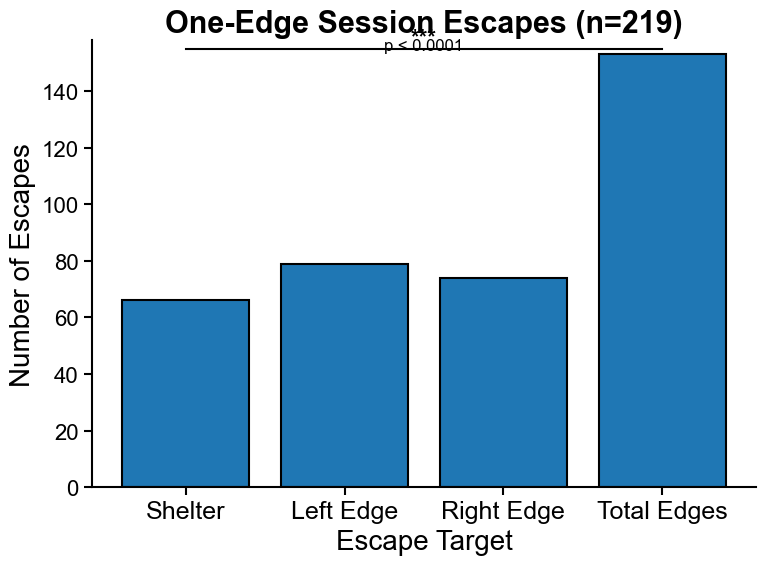

In [17]:
%matplotlib inline
hist_initial_heading_angle(one_edge_sessions_dict, "One-Edge Session Escapes", show_plots=True, plotting=True)

# spatial efficiency box plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_spatial_efficiency_boxplot(sessions, save_path=None, show_plot=True):
    """
    Extract spatial efficiency from two-edge task escapes and create a boxplot.
    
    Parameters:
    -----------
    sessions : dict
        Dictionary containing session data
    save_path : str, optional
        Path to save the figure
    show_plot : bool, optional
        Whether to show the plot
    """
    # Extract spatial efficiency values from all two-edge sessions
    all_spatial_efficiency = []
    
    for session_name, (onsets, offsets, tracking_data, escapes) in sessions.items():
        if isinstance(escapes.spatial_efficiency, (list, np.ndarray)):
            all_spatial_efficiency.extend(escapes.spatial_efficiency)
        else:
            all_spatial_efficiency.append(escapes.spatial_efficiency)
    
    # Calculate statistics
    mean_efficiency = np.mean(all_spatial_efficiency)
    median_efficiency = np.median(all_spatial_efficiency)
    std_efficiency = np.std(all_spatial_efficiency)
    
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })
    
    # Create boxplot
    fig, ax = plt.subplots(figsize=(7, 5))
    box = ax.boxplot(
        all_spatial_efficiency,
        patch_artist=True,
        boxprops=dict(facecolor="lightgrey", color="black"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker='o', color='black', alpha=0.5)
    )
    
    # Add labels and formatting
    ax.set_ylabel("Spatial Efficiency", fontsize=20)
    ax.set_title(f"Two-Edge Task Escapes (n={len(all_spatial_efficiency)})", fontsize=22, fontweight='bold')
    ax.set_xticks([])  # Remove x-ticks since there's only one condition
    
    # Add text with statistics
    ax.text(0.95, 0.05, f"Mean: {mean_efficiency:.3f}\nMedian: {median_efficiency:.3f}\nStd: {std_efficiency:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7), fontsize=14)
    
    # Format axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)  # Hide bottom spine since no x-ticks
    ax.spines["left"].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6)
    
    # Set y-axis limits to start slightly below min value and end slightly above max value
    y_min = min(all_spatial_efficiency) * 0.95
    y_max = max(all_spatial_efficiency) * 1.05
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the figure if path is provided
    if save_path:
        plt.savefig(os.path.join(save_path, "spatial_efficiency_two_edge.eps"), 
                   format="eps", bbox_inches="tight", dpi=300)
    
    if show_plot:
        
    else:
        plt.close()
    
    return all_spatial_efficiency

# Use with your sessions data
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
spatial_efficiencies = plot_spatial_efficiency_boxplot(sessions, save_path=save_path)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


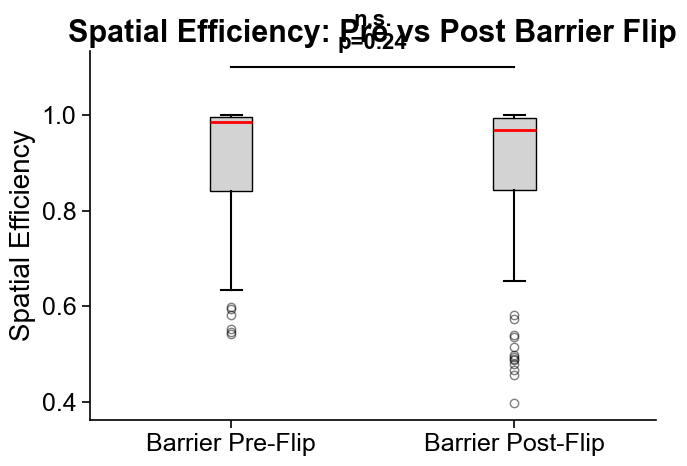

Pre-flip N: 80, mean: 0.909
Post-flip N: 102, mean: 0.882
T-test p-value: 0.2397, significance: n.s.


In [19]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def plot_spatial_efficiency_pre_vs_post(one_edge_sessions_dict, save_path=None):
    pre_flip_eff = []
    post_flip_eff = []

    # Loop through sessions and collect spatial efficiency by condition
    for session_name, (onsets, offsets, tracking_data, escapes) in one_edge_sessions_dict.items():
        conditions = escapes.escape_condition
        efficiencies = escapes.spatial_efficiency
        for cond, eff in zip(conditions, efficiencies):
            if cond == "barrier_pre_flip":
                pre_flip_eff.append(eff)
            elif cond == "barrier_post_flip":
                post_flip_eff.append(eff)

    # Convert to numpy arrays for stats
    pre_flip_eff = np.array(pre_flip_eff)
    post_flip_eff = np.array(post_flip_eff)

    # Boxplot
    plt.rcParams.update({
        "font.size": 18,
        "font.family": "Arial",
        "axes.labelsize": 20,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
    })
    fig, ax = plt.subplots(figsize=(7, 5))
    box = ax.boxplot(
        [pre_flip_eff, post_flip_eff],
        patch_artist=True,
        boxprops=dict(facecolor="lightgrey", color="black"),
        medianprops=dict(color="red", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker='o', color='black', alpha=0.5)
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Barrier Pre-Flip", "Barrier Post-Flip"])
    ax.set_ylabel("Spatial Efficiency")
    ax.set_title("Spatial Efficiency: Pre vs Post Barrier Flip", fontsize=22, fontweight='bold')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=6)

    # T-test and annotation
    tstat, pval = ttest_ind(pre_flip_eff, post_flip_eff, nan_policy='omit')
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    else:
        stars = 'n.s.'
    y_max = max(np.nanmax(pre_flip_eff), np.nanmax(post_flip_eff))
    y = y_max + 0.1 * y_max
    ax.plot([1, 2], [y, y], color='black', linewidth=1.5)
    ax.text(1.5, y + 0.03 * y_max, f"{stars}\np={pval:.3g}", ha='center', va='bottom', fontsize=16, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(os.path.join(save_path, "spatial_efficiency_pre_vs_post_flip.eps"), format='eps', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Pre-flip N: {len(pre_flip_eff)}, mean: {np.mean(pre_flip_eff):.3f}")
    print(f"Post-flip N: {len(post_flip_eff)}, mean: {np.mean(post_flip_eff):.3f}")
    print(f"T-test p-value: {pval:.4g}, significance: {stars}")

# Usage:
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
plot_spatial_efficiency_pre_vs_post(one_edge_sessions_dict, save_path=save_path)

# Plot spatial efficiency over time

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_spatial_efficiency_over_time(sessions, save_path=None, show_plot=True):
    """
    Plot spatial efficiency trends over sequential escape attempts for each session.
    
    Parameters:
    -----------
    sessions : dict
        Dictionary containing session data with format:
        {session_name: (onsets, offsets, tracking_data, escapes)}
    save_path : str, optional
        Path to save the figure
    show_plot : bool, optional
        Whether to show the plot
    """
    # Configure plot parameters for publication
    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Arial",
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    })
    
    # Create a 2x2 grid for the four sessions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Spatial Efficiency Across Sequential Escape Attempts", fontsize=20, fontweight='bold')
    
    # Define markers and colors for plotting
    markers = ['o', 's', 'd', '^']
    colors = ['steelblue', 'darkorange', 'forestgreen', 'darkred']
    
    # Flatten axes for easier iteration
    axes = axes.flatten()
    
    # Track overall trend across all sessions
    all_indices = []
    all_efficiencies = []
    
    # Plot each session
    for i, (session_name, (onsets, offsets, tracking_data, escapes)) in enumerate(sessions.items()):
        ax = axes[i]
        
        # Get spatial efficiency values
        if isinstance(escapes.spatial_efficiency, (list, np.ndarray)):
            spatial_efficiencies = escapes.spatial_efficiency
        else:
            spatial_efficiencies = [escapes.spatial_efficiency]
        
        # Create indices for escape sequence (starting from 1)
        indices = list(range(1, len(spatial_efficiencies) + 1))
        
        # Track valid data for trend line
        valid_indices = []
        valid_efficiencies = []
        
        # Plot individual points
        for j, (idx, eff) in enumerate(zip(indices, spatial_efficiencies)):
            if not np.isnan(eff):  # Skip NaN values
                ax.scatter(idx, eff, s=80, marker=markers[i], color=colors[i], 
                          edgecolor='black', linewidth=1, alpha=0.7)
                valid_indices.append(idx)
                valid_efficiencies.append(eff)
                
                # Add to overall data for trend analysis
                all_indices.append(idx)
                all_efficiencies.append(eff)
        
        # Fit a trend line if there are enough valid points
        if len(valid_indices) > 1:
            z = np.polyfit(valid_indices, valid_efficiencies, 1)
            p = np.poly1d(z)
            
            # Calculate correlation coefficient and p-value
            from scipy.stats import pearsonr
            corr, p_val = pearsonr(valid_indices, valid_efficiencies)
            
            # Plot trend line
            ax.plot(valid_indices, p(valid_indices), '-', color=colors[i], 
                   linewidth=2, alpha=0.8)
            
            # Add correlation info
            trend_text = f"Slope: {z[0]:.4f}\nCorr: {corr:.3f}\np-value: {p_val:.3f}"
            ax.text(0.05, 0.95, trend_text, transform=ax.transAxes, 
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # Add labels and formatting
        ax.set_title(f"{session_name} (n={len(valid_indices)})", fontsize=16)
        ax.set_xlabel("Escape Attempt Number", fontsize=14)
        ax.set_ylabel("Spatial Efficiency", fontsize=14)
        
        # Set consistent y-axis limits across all subplots
        ax.set_ylim(0, 1.1)
        
        # Add horizontal line at efficiency = 1 (perfect efficiency)
        ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
        
        # Format axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)
        ax.tick_params(width=1.2, length=6)
        
        # Set x-axis to show integer ticks only
        ax.set_xticks(indices)
        
        # Add grid for better readability
        ax.grid(True, linestyle='--', alpha=0.3)
    
    # Add a fifth subplot for the overall trend across all sessions
    if len(all_indices) > 0 and len(all_efficiencies) > 0:
        # Create a new figure for the overall trend
        fig_overall, ax_overall = plt.subplots(figsize=(8, 6))
        
        # Plot all points
        ax_overall.scatter(all_indices, all_efficiencies, s=80, color='purple', 
                          alpha=0.5, edgecolor='black')
        
        # Fit trend line
        if len(all_indices) > 1:
            z_all = np.polyfit(all_indices, all_efficiencies, 1)
            p_all = np.poly1d(z_all)
            
            # Calculate correlation
            corr_all, p_val_all = pearsonr(all_indices, all_efficiencies)
            
            # Plot trend line
            x_range = np.array([min(all_indices), max(all_indices)])
            ax_overall.plot(x_range, p_all(x_range), '-', color='darkred', 
                           linewidth=3, alpha=0.8)
            
            # Add correlation info
            overall_text = f"Slope: {z_all[0]:.4f}\nCorr: {corr_all:.3f}\np-value: {p_val_all:.3f}"
            ax_overall.text(0.05, 0.95, overall_text, transform=ax_overall.transAxes, 
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # Add labels and formatting
        ax_overall.set_title("Overall Trend Across All Sessions", fontsize=18, fontweight='bold')
        ax_overall.set_xlabel("Escape Attempt Number", fontsize=16)
        ax_overall.set_ylabel("Spatial Efficiency", fontsize=16)
        ax_overall.set_ylim(0, 1.1)
        ax_overall.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
        
        # Format axes
        ax_overall.spines["top"].set_visible(False)
        ax_overall.spines["right"].set_visible(False)
        ax_overall.spines["left"].set_linewidth(1.2)
        ax_overall.spines["bottom"].set_linewidth(1.2)
        ax_overall.tick_params(width=1.2, length=6)
        ax_overall.grid(True, linestyle='--', alpha=0.3)
        
        # Save overall trend figure
        if save_path:
            fig_overall.tight_layout()
            fig_overall.savefig(os.path.join(save_path, "spatial_efficiency_overall_trend.eps"), 
                               format="eps", bbox_inches="tight", dpi=300)
    
    # Adjust layout for the session subplots
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(os.path.join(save_path, "spatial_efficiency_over_time.eps"), 
                   format="eps", bbox_inches="tight", dpi=300)
    

# Run the function with your sessions data
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
plot_spatial_efficiency_over_time(sessions, save_path=save_path)